**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# Write your code here
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

%load_ext autoreload
%autoreload 2
from examproject import CareerClass

## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

In [2]:
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000

par.F = np.arange(1,par.N+1)
par.sigma = 2

par.v = np.array([1,2,3])
par.c = 1

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.


In [3]:
import numpy as np
from types import SimpleNamespace

# Chatgpt

# Define the parameters
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000
par.F = np.arange(1, par.N + 1)
par.sigma = 2
par.v = np.array([1, 2, 3])
par.c = 1

# Question 1: Simulate and calculate expected utility and the average realized utility for K draws, for each career choice j.

def simulate_expected_utility(par):
    # Initialize arrays to store results
    expected_utilities = np.zeros(par.J)
    realized_utilities = np.zeros(par.J)
    
    for j in range(par.J):
        # Draw K values from normal distribution for each career track
        epsilon = np.random.normal(0, par.sigma, par.K)
        
        # Calculate the utility for each draw
        utilities = par.v[j] + epsilon
        
        # Calculate expected utility
        expected_utilities[j] = np.mean(utilities)
        
        # Calculate realized utility
        realized_utilities[j] = np.mean(utilities)
        
    return expected_utilities, realized_utilities

expected_utilities, realized_utilities = simulate_expected_utility(par)

expected_utilities, realized_utilities


(array([0.99587928, 1.98065981, 2.99558021]),
 array([0.99587928, 1.98065981, 2.99558021]))

In [4]:
# initialize class
career = CareerClass()

seed = None
# check what the sum of 10.000 draws from a standard normal distribution is when using seed=2024
print (f'The sum of 10.000 draws from a normal distribution using seed 2024 is {career.simulate(seed=seed):.2f}\n')

# calculate the expected utility for each career path
for v in par.v:
    print (f'The expected utility for career path {v} is {career.expec_utility(v, seed=1):.3f}')

# calculate average realised utility
for v in par.v:
    print(f'The average realised utility for career path {v} is {career.avg_real_utility(v, seed):.3f}')

if career.avg_real_utility(1, seed) == career.expec_utility(1,seed):
    print(f'True')
else:
    print(f'False')

The sum of 10.000 draws from a normal distribution using seed 2024 is -182.66

The expected utility for career path 1 is 1.020
The expected utility for career path 2 is 2.020
The expected utility for career path 3 is 3.020
The average realised utility for career path 1 is 1.019
The average realised utility for career path 2 is 1.971
The average realised utility for career path 3 is 3.032
False


Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

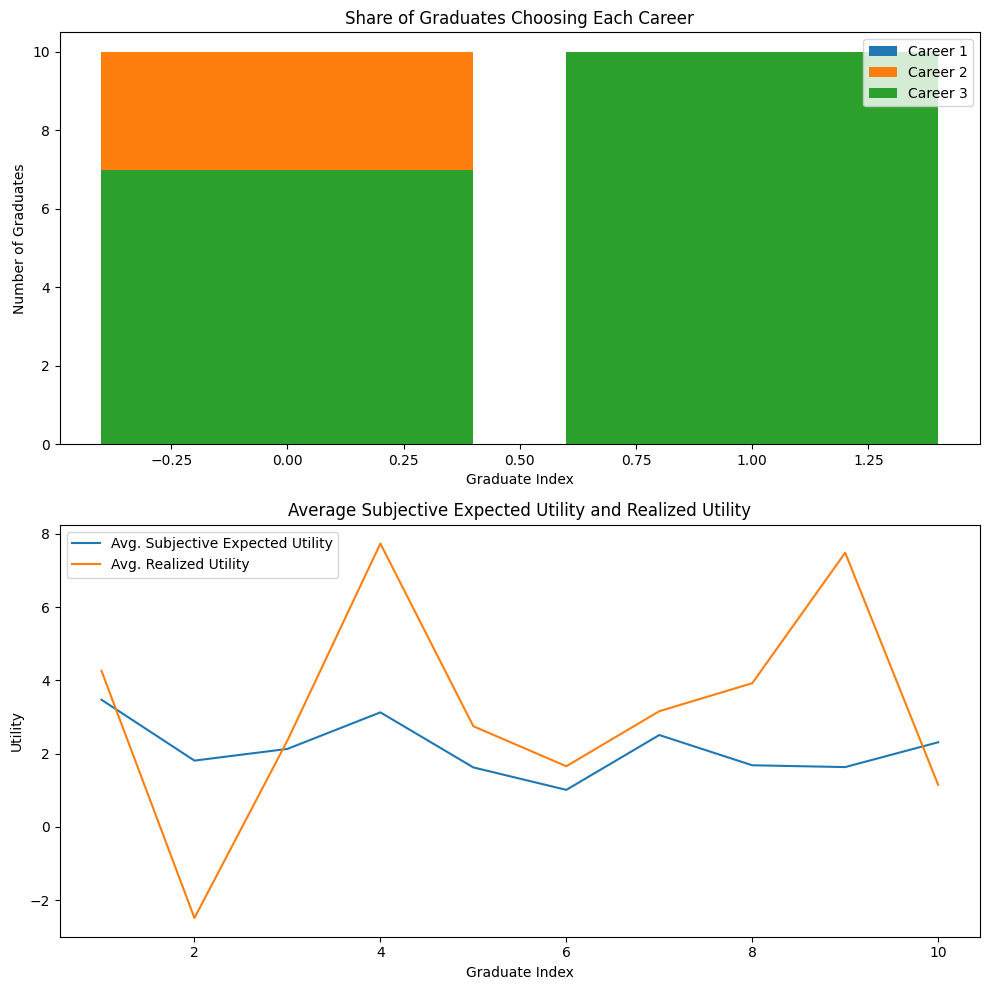

In [76]:
# Write your answer here 

par.i = np.array([1,2,3,4,5,6,7,8,9,10])

#maybe need to change the size of draws to 



# Simulate prior expected utility, chosen careers, and realized utilities based on friends' information
prior_expec_util, chosen_career, real_util = career.prior_expec()

# Visualization
choices = np.zeros((career.par.N, career.par.J))
for i in range(career.par.N):
    choices[i, chosen_career[i]] += 1

career.visualize_results(choices, np.mean(prior_expec_util, axis=1), real_util)



In [60]:
real_util

array([2.36073727, 6.14926815, 3.12734332, 1.71621284, 2.73891707,
       3.03399376, 6.21974797, 2.88673483, 5.33661727, 2.4028588 ])

In [61]:
prior_expec_util

array([[-0.07325872,  2.63080534,  3.84210143],
       [ 0.28547828,  2.78605306,  5.27482386],
       [ 1.10150377,  1.88401462,  3.65798471],
       [ 0.43441746,  3.17978442,  2.72961273],
       [ 0.84978604,  2.56633883,  2.79093607],
       [ 1.38992725,  2.62044975,  2.74660947],
       [ 1.00684454,  2.05676158,  2.56175525],
       [ 0.01392   ,  1.94937107,  2.98015715],
       [ 0.76754937,  1.80807191,  2.99489488],
       [ 0.60533031,  1.25649651,  3.26352095]])

In [77]:
chosen_career

array([1, 2, 2, 2, 2, 2, 1, 2, 2, 2])

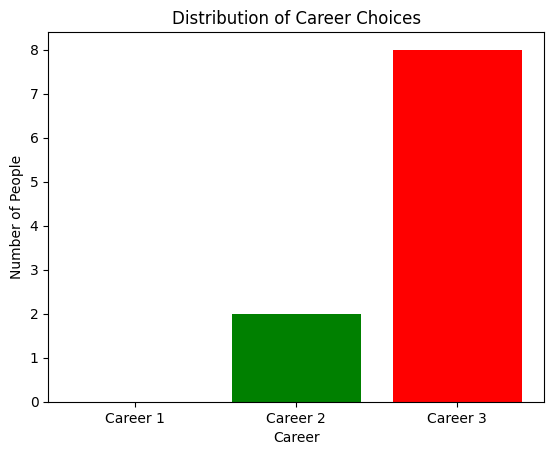

In [81]:
# Count the number of people choosing each career
career_counts = np.bincount(chosen_career)

# Define career labels
career_labels = ['Career 1', 'Career 2', 'Career 3']

# Plot the bar chart
plt.bar(career_labels, career_counts, color=['blue', 'green', 'red'])
plt.title('Distribution of Career Choices')
plt.xlabel('Career')
plt.ylabel('Number of People')
plt.show()

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>

In [82]:
# write your answer here

par.c = 1

def simulate_career_switching(par, chosen_career, prior_expec_util, real_util):
    np.random.seed(11)  # For reproducibility
    
    new_chosen_career = np.zeros(par.N, dtype=int)
    new_real_util = np.zeros(par.N)
    eps_self = np.zeros((par.N, par.J))
    adjusted_priors = np.zeros((par.N, par.J))
    switch_decisions = np.zeros(par.N, dtype=int)

    for i in range(par.N):
        
        # Initial chosen career and realized utility
        initial_career = chosen_career[i]
        initial_realized_utility = real_util[i]
        eps_self[i] = np.random.normal(0, par.sigma, par.J)
        for j in range(par.J):
            initial_expected_utility = prior_expec_util[i, j]
            if j != initial_career:
                adjusted_priors[i, j] = initial_expected_utility - par.c
            else:
                adjusted_priors[i, j] = initial_realized_utility

        # Choose the career with the highest expected utility
        new_chosen_career[i] = np.argmax(adjusted_priors[i])
        new_real_util[i] = par.v[new_chosen_career[i]] + eps_self[i, new_chosen_career[i]]
        # Record if the graduate decided to switch careers
        switch_decisions[i] = 1 if new_chosen_career[i] != initial_career else 0
    
    return new_chosen_career, switch_decisions, adjusted_priors, new_real_util

# Run the simulation

new_chosen_career, switch_decisions, adjusted_priors, new_real_util = simulate_career_switching(par, chosen_career, prior_expec_util, real_util)

print("New chosen careers:", new_chosen_career)
print("New expected:", adjusted_priors)
print("New realized:", new_real_util)
print("Switch decisions:", switch_decisions)


New chosen careers: [1 1 2 2 2 2 1 2 2 1]
New expected: [[ 0.7854355   4.26325024  0.3090087 ]
 [-1.88361381  0.30846044 -2.48386115]
 [-1.83358927  1.87909037  2.36124677]
 [ 2.03750485  1.06411518  7.7365169 ]
 [-0.11220317  0.15312766  2.75006635]
 [-0.3423263  -0.61388203  1.65814923]
 [ 0.08677069  3.16026161  1.74619652]
 [-0.22972085  1.03165168  3.92420033]
 [-0.97417621  0.7843995   7.48619911]
 [-0.03523381  1.33044281  1.15013902]]
New realized: [1.42785401 1.98343074 3.84210143 2.04853301 0.38890298 6.14926815
 0.63310675 6.09814327 4.46454271 1.64381365]
Switch decisions: [0 1 0 0 0 0 0 0 0 1]


In [79]:
# Number of iterations
K = 10000

# Initialize cumulative results
cumulative_adjusted_priors = np.zeros((par.N, par.J))
cumulative_new_real_util = np.zeros(par.N)
cumulative_new_chosen_career = np.zeros(par.J)
cumulative_switch_decisions = 0

for _ in range(K):
    new_chosen_career, switch_decisions, adjusted_priors, new_real_util = simulate_career_switching(par, chosen_career, prior_expec_util, real_util)
    
    cumulative_adjusted_priors += adjusted_priors
    cumulative_new_real_util += new_real_util
    
    for i in range(par.J):
        cumulative_new_chosen_career[i] += np.sum(new_chosen_career == i)
    
    cumulative_switch_decisions += np.sum(switch_decisions)

# Calculate averages
average_adjusted_priors = cumulative_adjusted_priors / K
average_new_real_util = cumulative_new_real_util / K
share_new_chosen_career = cumulative_new_chosen_career / (par.N * K)
share_switch_decisions = cumulative_switch_decisions / (par.N * K)

# Print results
print("Average adjusted priors:\n", average_adjusted_priors)
print("Average new realized utilities:\n", average_new_real_util)
print("Share of new chosen careers:\n", share_new_chosen_career)
print("Share of switch decisions:\n", share_switch_decisions)

Average adjusted priors:
 [[ 0.7854355   4.26325024  0.3090087 ]
 [-1.88361381  0.30846044 -2.48386115]
 [-1.83358927  1.87909037  2.36124677]
 [ 2.03750485  1.06411518  7.7365169 ]
 [-0.11220317  0.15312766  2.75006635]
 [-0.3423263  -0.61388203  1.65814923]
 [ 0.08677069  3.16026161  1.74619652]
 [-0.22972085  1.03165168  3.92420033]
 [-0.97417621  0.7843995   7.48619911]
 [-0.03523381  1.33044281  1.15013902]]
Average new realized utilities:
 [1.42785401 1.98343074 3.84210143 2.04853301 0.38890298 6.14926815
 0.63310675 6.09814327 4.46454271 1.64381365]
Share of new chosen careers:
 [0.  0.4 0.6]
Share of switch decisions:
 0.2


In [83]:
cumulative_switch_decisions

20000